In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine 
import seaborn as sns

### Конфигурация для подключения к базе данных `data-analyst-advanced-sql`

In [8]:
db_config = {
    'user': 'praktikum_student', # имя пользователя
    'pwd': 'Sdf4$2;d-d30pp', # пароль
    'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
    'port': 6432, # порт подключения
    'db': 'data-analyst-advanced-sql' # название базы данных
}  

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
)

Создание подключения

In [9]:
engine = create_engine(connection_string) 

Пример запроса к базе данных

`sample_df` является pandas-датафреймом.

In [10]:
query = '''
SELECT *
FROM stackoverflow.users
LIMIT 10;
'''

sample_df = pd.read_sql_query(query, con=engine) 

In [11]:
sample_df

,id,creation_date,display_name,last_access_date,location,reputation,views
0,1,2008-07-31 14:22:31,Jeff Atwood,2018-08-29 02:34:23,"El Cerrito, CA",44300,408587
1,2,2008-07-31 14:22:31,Geoff Dalgas,2018-08-23 17:31:56,"Corvallis, OR",3491,23966
2,3,2008-07-31 14:22:31,Jarrod Dixon,2018-08-30 20:56:24,"Raleigh, NC, United States",13418,24396
3,4,2008-07-31 14:22:31,Joel Spolsky,2018-08-14 22:18:15,"New York, NY",28768,73755
4,5,2008-07-31 14:22:31,Jon Galloway,2018-08-29 16:48:36,"San Diego, CA",39172,11700
5,8,2008-07-31 21:33:24,Eggs McLaren,2018-04-09 02:04:56,NaN,942,6372
6,9,2008-07-31 21:35:27,Kevin Dente,2018-08-30 18:18:03,"Oakland, CA",14337,4949
7,11,2008-08-01 00:59:11,Anonymous User,2008-08-01 00:59:11,NaN,1890,2123
8,13,2008-08-01 04:18:05,Chris Jester-Young,2018-08-30 02:47:23,"Raleigh, NC, United States",177138,35414
9,17,2008-08-01 12:02:22,Nick Berardi,2018-01-22 01:35:38,"Issaquah, WA",44443,4786


# Задание 1

Выведите общую сумму просмотров постов за каждый месяц 2008 года. Если данных за какой-либо месяц в базе нет, такой месяц можно пропустить. Результат отсортируйте по убыванию общего количества просмотров.

| month_date  | total_views |
| ------------- | ------------- |
| 2008-09-01  | 452928568  |
| 2008-10-01  | 365400138  |
| ...         | ... |

In [12]:
# напишите запрос
query = '''
SELECT DISTINCT
    DATE_TRUNC('month', creation_date) AS month_date,
    SUM(views_count) AS total_views
FROM stackoverflow.posts
GROUP BY DATE_TRUNC('month', creation_date)
ORDER BY total_views DESC
LIMIT 10
'''

# выполните запрос
pd.read_sql_query(query, engine)

,month_date,total_views
0,2008-09-01,452928568
1,2008-10-01,365400138
2,2008-11-01,221759651
3,2008-12-01,197792841
4,2008-08-01,131367083
5,2008-07-01,669895


Проанализируйте итоговую таблицу. Отличаются ли данные за разные месяцы? С чем могут быть связаны отличия?

Летом количество запросов гораздо меньше, больше всего запросов в сентябре

# Задание 2

Выведите имена самых активных пользователей, которые в первый месяц после регистрации (включая день регистрации) дали больше 100 ответов. Вопросы, которые задавали пользователи, не учитывайте. Для каждого имени пользователя выведите количество уникальных значений `user_id`. Отсортируйте результат по полю с именами в лексикографическом порядке.

| display_name | count |
| ------------ | ----- |
| 1800 INFORMATION | 1 |
| Adam Bellaire | 1 |
| Adam Davis | 1 |
| ... | ... |

In [13]:
# напишите запрос
query = '''

SELECT u.display_name, COUNT(DISTINCT u.id)
FROM stackoverflow.posts p
JOIN stackoverflow.users u ON u.id = p.user_id

WHERE p.post_type_id IN (
    SELECT id 
    FROM stackoverflow.post_types
    WHERE type = 'Answer'
) AND p.creation_date - u.creation_date <= '30 day'

GROUP BY u.display_name
HAVING COUNT(*) > 100
ORDER BY u.display_name
LIMIT 10

'''

# выполните запрос
pd.read_sql_query(query, engine)

,display_name,count
0,1800 INFORMATION,1
1,Adam Bellaire,1
2,Adam Davis,1
3,Adam Liss,1
4,Alan,8
5,Amy B,1
6,Ben Hoffstein,1
7,Brian,15
8,Cade Roux,1
9,CesarB,1


Какие аномалии наблюдаются в данных? О чём они говорят?

# Задание 3

Выведите количество постов за 2008 год по месяцам. Отберите посты от пользователей, которые зарегистрировались в сентябре 2008 года и сделали хотя бы один пост в декабре того же года. Отсортируйте таблицу по значению месяца по убыванию.

| month | count |
| ------|------ |
| 2008-12-01 | 17641 |
| 2008-11-01 | 18294 |
| ... | ... |

In [14]:
# напишите запрос
query = '''
SELECT DATE_TRUNC('month', creation_date) AS month, COUNT(*)
FROM stackoverflow.posts
WHERE user_id in (
    SELECT id
    FROM stackoverflow.users
    WHERE DATE_TRUNC('month', creation_date) = '2008-09-01'
)
AND user_id in (
    SELECT user_id
    FROM stackoverflow.posts
    WHERE DATE_TRUNC('month', creation_date) = '2008-12-01'
)
AND EXTRACT(YEAR FROM creation_date) = 2008

GROUP BY DATE_TRUNC('month', creation_date)
ORDER BY month DESC
'''

# выполните запрос
pd.read_sql_query(query, engine)

,month,count
0,2008-12-01,17658
1,2008-11-01,18312
2,2008-10-01,27195
3,2008-09-01,24890
4,2008-08-01,32


Изучите данные: есть ли в них аномалии? Предположите, почему могли появиться аномальные значения.

Меньше всего постов летом, больше всего - в сентябре. К концу года количество снижается, это связано с тем, что студенты наиболее активно занимаются программированием именно в начале учебного года.

# Задание 4

Используя данные о постах, выведите несколько полей:

- идентификатор пользователя, который написал пост;
- дата создания поста;
- количество просмотров у текущего поста;
- сумму просмотров постов автора с накоплением.

Данные в таблице должны быть отсортированы по возрастанию идентификаторов пользователей, а данные об одном и том же пользователе — по возрастанию даты создания поста.

| user_id | creation_date | views_count | cumulative_count |
| ------ | -------------- | ----------- | ---------------- |
| 1 | 2008-07-31 23:41:00  | 480476   | 480476  |
| 1 | 2008-07-31 23:55:38  | 136033 | 616509  | 
| 1 | 2008-07-31 23:56:41  | 0 |  616509  |
| ... | ... | ... | ... |
| 2 | 2008-07-31 23:56:41 | 79087  | 79087 |
| 2 | 2008-08-01 05:09:56 | 65443 | 144530 |
| ... | ...  | ...  | ...  |

In [15]:
# напишите запрос
query = '''
SELECT 
    user_id,
    creation_date,
    views_count,
    SUM(views_count) OVER(PARTITION BY user_id ORDER BY creation_date) AS cumulative_count
FROM stackoverflow.posts
LIMIT 72
'''

# выполните запрос
pd.read_sql_query(query, engine)

,user_id,creation_date,views_count,cumulative_count
0,1,2008-07-31 23:41:00,480476,480476
1,1,2008-07-31 23:55:38,136033,616509
2,1,2008-07-31 23:56:41,0,616509
3,1,2008-08-04 02:45:08,0,616509
4,1,2008-08-04 04:31:03,0,616509
...,...,...,...,...
67,1,2008-12-23 11:00:13,0,1039890
68,1,2008-12-24 13:07:56,0,1039890
69,1,2008-12-30 08:23:07,0,1039890
70,2,2008-08-01 04:59:34,79087,79087


# Задание 5

Найдите среднее количество постов пользователей в день за август 2008 года. Отберите данные о пользователях, которые опубликовали больше 120 постов за август. Дни без публикаций не учитывайте. 

Отсортируйте результат по возрастанию среднего количества постов. Значения можно не округлять.

| user_id | avg_daily |
| ------- | --------- |
| 116     | 4.777778  |
| 234     | 5.208333  |
| ...     | ... |

In [16]:
# напишите запрос
query = '''
SELECT 
    user_id,
    AVG(count)
FROM (
    SELECT user_id, DATE_TRUNC('day', creation_date), COUNT(*)
    FROM stackoverflow.posts
    WHERE DATE_TRUNC('month', creation_date) = '2008-08-01'
    GROUP BY user_id, DATE_TRUNC('day', creation_date)
) posts_per_user
GROUP BY user_id
HAVING SUM(count) > 120
ORDER BY avg
'''

pd.read_sql_query(query, engine)

,user_id,avg
0,116,4.777778
1,234,5.208333
2,91,5.681818
3,905,7.000000
4,383,7.277778


# Задание 6

Сколько в среднем дней в период с 1 по 7 декабря 2008 года пользователи взаимодействовали с платформой? Для каждого пользователя отберите дни, в которые он или она опубликовали хотя бы один пост. Нужно получить одно целое число — не забудьте округлить результат. 

| result |
| -----  |
| <целое число> |

In [17]:
# напишите запрос
query = '''
SELECT ROUND(AVG(count)) AS result
FROM (
    SELECT user_id, COUNT(DISTINCT(DATE_TRUNC('day', creation_date)))
    FROM stackoverflow.posts
    WHERE creation_date BETWEEN '2008-12-01' AND '2008-12-08'
    GROUP BY user_id
) t
'''

# выполните запрос
pd.read_sql_query(query, engine)

,result
0,2.0


Проанализируйте итоговую таблицу — какие выводы можно сделать?

# Задание 7

Выведите историю активности каждого пользователя в таком виде: идентификатор пользователя, дата публикации поста. Отсортируйте вывод по возрастанию идентификаторов пользователей, а для каждого пользователя — по возрастанию даты публикации.

Добавьте в таблицу новое поле: для каждого поста в нём будет указано название месяца предпоследней публикации пользователя относительно текущей. Если такой публикации нет, укажите `NULL`.  Python автоматически поменяет `NULL` на `None`, но дополнительно преобразовывать значения `None` вам не нужно.

Посмотрите внимательно на образец таблицы: для первых двух постов предпоследней публикации нет, но, начиная с третьего поста, в новое поле входит нужный месяц. Для следующего пользователя в первые две записи поля `second_last_month` тоже войдёт `NULL`.

| user_id | creation_date | second_last_month |
| ------- | ------------- | ----------------- |
| 1       | 2008-07-31 23:41:00 | None |
| 1       | 2008-07-31 23:55:38 | None |
| 1       | 2008-07-31 23:56:41 | July |
| 1       | 2008-08-04 02:45:08 | July |
| 1       | 2008-08-04 04:31:03 | July |
| 1       | 2008-08-04 08:04:42 | August |
| ... | ... | ... |

In [19]:
# напишите запрос
query = '''
SELECT
    user_id,
    creation_date,
    TO_CHAR((LAG(creation_date, 2) OVER(PARTITION BY user_id ORDER BY creation_date))::date, 'Month') AS second_last_month
FROM stackoverflow.posts
LIMIT 6
'''

pd.read_sql_query(query, engine)

,user_id,creation_date,second_last_month
0,1,2008-07-31 23:41:00,NaN
1,1,2008-07-31 23:55:38,NaN
2,1,2008-07-31 23:56:41,July
3,1,2008-08-04 02:45:08,July
4,1,2008-08-04 04:31:03,July
5,1,2008-08-04 08:04:42,August


# Задание 8

Рассчитайте аналог Retention Rate по месяцам для пользователей StackOverflow. Объедините пользователей в когорты по месяцу их первого поста. Возвращение определяйте по наличию поста в текущем месяце. 

| cohort_dt | session_date | users_cnt | cohort_users_cnt | retention_rate |
| --- | --- | --- | --- | --- |
| 2008-07-01 00:00:00 | 2008-07-01 00:00:00 | 3 | 3 | 100 |
| 2008-07-01 00:00:00 | 2008-08-01 00:00:00 | 2 | 3 | 66,67 |
| 2008-07-01 00:00:00 | 2008-09-01 00:00:00 | 1 | 3 | 33,33 |
| 2008-07-01 00:00:00 | 2008-10-01 00:00:00 | 2 | 3 | 66,67 |
| 2008-07-01 00:00:00 | 2008-11-01 00:00:00 | 1 | 3 | 33,33 |
| 2008-07-01 00:00:00 | 2008-12-01 00:00:00 | 2 | 3 | 66,67 |
| 2008-08-01 00:00:00 | 2008-08-01 00:00:00 | 2151 | 2151 | 100 |
| ... | ... | ... | ... | ... |

In [20]:
# напишите запрос
query = '''
WITH cohorts AS (
    SELECT user_id, 
        cohort_dt, 
        COUNT(user_id) OVER(PARTITION BY cohort_dt) AS cohort_users_cnt
    FROM (
        SELECT DISTINCT 
            user_id,
            FIRST_VALUE(DATE_TRUNC('month', creation_date)) OVER(PARTITION BY user_id ORDER BY creation_date) AS cohort_dt
        FROM stackoverflow.posts
    ) cohorts
), sessions AS (
    SELECT user_id,
        DATE_TRUNC('month', creation_date) AS session_dt
    FROM stackoverflow.posts
    GROUP BY user_id, DATE_TRUNC('month', creation_date)
)
SELECT cohort_dt, 
    session_dt, 
    COUNT(sessions) AS users_cnt, 
    cohort_users_cnt,
    ROUND(COUNT(sessions) * 100. / cohort_users_cnt, 2) AS retention_rate
FROM cohorts
JOIN sessions USING(user_id)

GROUP BY cohort_dt, session_dt, cohort_users_cnt
ORDER BY cohort_dt, session_dt
'''

retention_df = pd.read_sql_query(query, engine)
retention_df.head()

,cohort_dt,session_dt,users_cnt,cohort_users_cnt,retention_rate
0,2008-07-01,2008-07-01,3,3,100.00
1,2008-07-01,2008-08-01,2,3,66.67
2,2008-07-01,2008-09-01,1,3,33.33
3,2008-07-01,2008-10-01,2,3,66.67
4,2008-07-01,2008-11-01,1,3,33.33


Постройте тепловую карту Retention Rate. Какие аномалии или другие необычные явления удалось выявить? Сформулируйте гипотезы о возможных причинах.

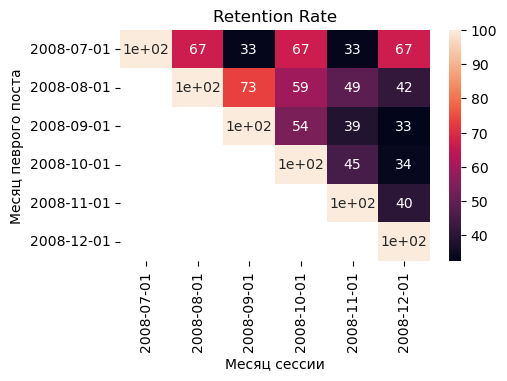

In [21]:
retention = retention_df.pivot(index='cohort_dt', columns='session_dt', values='retention_rate')
retention.index = [str(x)[0:10] for x in retention.index]
retention.columns = [str(x)[0:10] for x in retention.columns]

plt.figure(figsize=(5, 3))
sns.heatmap(
    retention,
    annot=True
)
plt.xlabel('Месяц сессии')
plt.ylabel('Месяц певрого поста')
plt.title('Retention Rate');

# Задание 9


На сколько процентов менялось количество постов ежемесячно с 1 сентября по 31 декабря 2008 года? Отобразите таблицу со следующими полями:

- номер месяца;
- количество постов за месяц;
- процент, который показывает, насколько изменилось количество постов в текущем месяце по сравнению с предыдущим.

Если постов стало меньше, значение процента должно быть отрицательным, если больше — положительным. Округлите значение процента до двух знаков после запятой.

Напомним, что при делении одного целого числа на другое в PostgreSQL в результате получится целое число, округлённое до ближайшего целого вниз. Чтобы этого избежать, переведите делимое в тип `numeric`.

| creation_month | posts_count | percentage |
| -------------- | ----------- | ---------- |
| 9 | 70731 | Nan |
| 10 | 63102 | -10.33 |
| ... | ... | ... |

In [22]:
# напишите запрос
query = '''
WITH posts_cnt AS (
    SELECT DATE_TRUNC('month', creation_date) AS creation_month,
        COUNT(*) AS costs_count
    FROM stackoverflow.posts
    WHERE creation_date >= '2008-09-01'
    GROUP BY DATE_TRUNC('month', creation_date)
)
SELECT creation_month, 
    costs_count,
    ROUND(costs_count::numeric * 100 / LAG(costs_count) OVER(ORDER BY creation_month) - 100, 2)
FROM posts_cnt
'''

posts_cnt_df = pd.read_sql_query(query, engine)
posts_cnt_df

,creation_month,costs_count,round
0,2008-09-01,70371,NaN
1,2008-10-01,63102,-10.33
2,2008-11-01,46975,-25.56
3,2008-12-01,44592,-5.07


Постройте круговую диаграмму с количеством постов по месяцам.

<Axes: title={'center': 'Количество постов по месяцам'}>

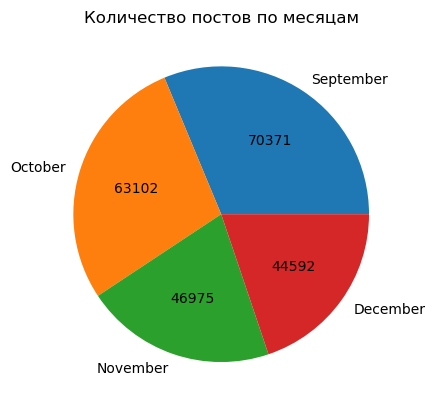

In [23]:
posts_cnt_df.plot(
    y="costs_count",
    labels=posts_cnt_df.creation_month.dt.month_name(),
    kind="pie",
    legend=False,
    title="Количество постов по месяцам",
    ylabel='',
    autopct=lambda p: f'{p*sum(posts_cnt_df["costs_count"])/100:.0f}'
)

# Задание 10

Выгрузите данные активности пользователя, который опубликовал больше всего постов за всё время. Выведите данные за октябрь 2008 года в таком виде:

- номер недели;
- дата и время последнего поста, опубликованного на этой неделе.

| week_creation | creation_date |
| ------------- | ------------- |
| 40 | 2008-10-05 09:00:58 |
| 41 | 2008-10-12 21:22:23 |
| ... | ... |

In [24]:
# напишите запрос
query = '''
WITH weeks AS (
    SELECT 
        EXTRACT(WEEK FROM creation_date) AS week_creation,
        LAST_VALUE(creation_date) OVER(
            PARTITION BY EXTRACT(WEEK FROM creation_date) 
            ORDER BY creation_date
            RANGE BETWEEN CURRENT ROW AND UNBOUNDED FOLLOWING
        )
    FROM stackoverflow.posts
    WHERE user_id = (
        SELECT user_id
        FROM stackoverflow.posts
        GROUP BY user_id
        ORDER BY COUNT(*) DESC
        LIMIT 1
    )
    AND EXTRACT(MONTH FROM creation_date) = '10'
    ORDER BY creation_date
)
SELECT DISTINCT * FROM weeks
'''

pd.read_sql_query(query, engine)

,week_creation,last_value
0,40.0,2008-10-05 09:00:58
1,41.0,2008-10-12 21:22:23
2,42.0,2008-10-19 06:49:30
3,43.0,2008-10-26 21:44:36
4,44.0,2008-10-31 22:16:01


# Задания из первой части

## Найдите количество вопросов, которые набрали больше 300 очков или как минимум 100 раз были добавлены в «Закладки».

In [25]:
query = '''

SELECT COUNT(*)
FROM stackoverflow.posts
WHERE (score > 300 OR favorites_count >= 100) 
AND post_type_id = (
    SELECT id
    FROM stackoverflow.post_types
    WHERE type = 'Question'
    LIMIT 1
)

'''
pd.read_sql_query(query, engine)

,count
0,1355


## Сколько в среднем в день задавали вопросов с 1 по 18 ноября 2008 включительно? Результат округлите до целого числа.

In [26]:
query = '''

SELECT ROUND(AVG(count))
FROM (
    SELECT COUNT(*)
    FROM stackoverflow.posts
    WHERE creation_date::date BETWEEN '2008-11-01' AND '2008-11-18'
        AND post_type_id = (
            SELECT id
            FROM stackoverflow.post_types
            WHERE type = 'Question'
            LIMIT 1
        )
    GROUP BY EXTRACT(DAY FROM creation_date)
) p

'''
pd.read_sql_query(query, engine)

,round
0,383.0


## Сколько пользователей получили значки сразу в день регистрации? Выведите количество уникальных пользователей.

In [27]:
query = '''

SELECT COUNT(id) FROM (
    SELECT DISTINCT u.id
    FROM stackoverflow.badges b
    JOIN stackoverflow.users u ON u.id = b.user_Id
    WHERE u.creation_date::date = b.creation_date::date
) i

'''
pd.read_sql_query(query, engine)

,count
0,7047


## Сколько уникальных постов пользователя с именем Joel Coehoorn получили хотя бы один голос?

In [28]:
query = '''

SELECT COUNT(*)
FROM stackoverflow.posts
WHERE user_id = (
    SELECT id 
    FROM stackoverflow.users 
    WHERE display_name = 'Joel Coehoorn'
) AND id IN (
    SELECT post_id 
    FROM stackoverflow.votes
)
'''
pd.read_sql_query(query, engine)

,count
0,12


## Выгрузите все поля таблицы vote_types. Добавьте к таблице поле rank, в которое войдут номера записей в обратном порядке. Таблица должна быть отсортирована по полю id.

In [29]:
query = '''

SELECT *, ROW_NUMBER() OVER(ORDER BY id DESC)
FROM stackoverflow.vote_types
ORDER BY id

'''
pd.read_sql_query(query, engine)

,id,name,row_number
0,1,AcceptedByOriginator,15
1,2,UpMod,14
2,3,DownMod,13
3,4,Offensive,12
4,5,Favorite,11
5,6,Close,10
6,7,Reopen,9
7,8,BountyStart,8
8,9,BountyClose,7
9,10,Deletion,6


## Отберите 10 пользователей, которые поставили больше всего голосов типа Close. 
Отобразите таблицу из двух полей: идентификатором пользователя и количеством голосов. Отсортируйте данные сначала по убыванию количества голосов, потом по убыванию значения идентификатора пользователя.

In [30]:
query = '''

SELECT user_id, COUNT(*)
FROM stackoverflow.votes
WHERE vote_type_id = (SELECT id FROM stackoverflow.vote_types WHERE name = 'Close')
GROUP BY user_id
ORDER BY count DESC, user_id DESC
LIMIT 10

'''
pd.read_sql_query(query, engine)

,user_id,count
0,20646,36
1,14728,36
2,27163,29
3,41158,24
4,24820,23
5,9345,23
6,3241,23
7,44330,20
8,38426,19
9,19074,19


## Отберите 10 пользователей по количеству значков, полученных в период с 15 ноября по 15 декабря 2008 года включительно.
Отобразите несколько полей:
- идентификатор пользователя;
- число значков;
- место в рейтинге — чем больше значков, тем выше рейтинг.\
Пользователям, которые набрали одинаковое количество значков, присвойте одно и то же место в рейтинге.
Отсортируйте записи по количеству значков по убыванию, а затем по возрастанию значения идентификатора пользователя.

In [31]:
query = '''
WITH badges_cnt AS (
    SELECT user_id, COUNT(*)
    FROM stackoverflow.badges
    WHERE creation_date::date BETWEEN '2008-11-15' AND '2008-12-15'
    GROUP BY user_id
    ORDER BY count DESC, user_id
)
SELECT user_id, count, DENSE_RANK() OVER(ORDER BY count DESC)
FROM badges_cnt
LIMIT 8
'''
pd.read_sql_query(query, engine)

,user_id,count,dense_rank
0,22656,149,1
1,34509,45,2
2,1288,40,3
3,5190,31,4
4,13913,30,5
5,893,28,6
6,10661,28,6
7,33213,25,7


## Сколько в среднем очков получает пост каждого пользователя?
Сформируйте таблицу из следующих полей:
- заголовок поста;
- идентификатор пользователя;
- число очков поста;
- среднее число очков пользователя за пост, округлённое до целого числа.\
Не учитывайте посты без заголовка, а также те, что набрали ноль очков.

In [32]:
query = '''

SELECT 
    title,
    user_id,
    score,
    ROUND(AVG(score) OVER(PARTITION BY user_id))
FROM stackoverflow.posts
WHERE title IS NOT NULL AND score != 0
LIMIT 15
'''
pd.read_sql_query(query, engine)

,title,user_id,score,round
0,Practical non-image based CAPTCHA approaches?,1,318,573.0
1,Diagnosing Deadlocks in SQL Server 2005,1,82,573.0
2,Calculate relative time in C#,1,1348,573.0
3,How do I calculate someone's age in C#?,1,1743,573.0
4,Escaping Bracket [ in a CONTAINS() clause?,1,10,573.0
5,Wrapping StopWatch timing with a delegate or l...,1,92,573.0
6,Why doesn't IE7 copy <pre><code> blocks to the...,1,37,573.0
7,Parameterize an SQL IN clause,1,953,573.0
8,Filling a DataSet or DataTable from a LINQ que...,2,114,76.0
9,Binary Data in MySQL,2,169,76.0


## Отобразите заголовки постов, которые были написаны пользователями, получившими более 1000 значков. Посты без заголовков не должны попасть в список.

In [33]:
query = '''

    SELECT title
    FROM stackoverflow.posts
    WHERE user_id IN (
        SELECT user_id
        FROM stackoverflow.badges
        GROUP BY user_id
        HAVING COUNT(*) > 1000
    ) AND title IS NOT NULL

'''
pd.read_sql_query(query, engine)

,title
0,What's the strangest corner case you've seen i...
1,What's the hardest or most misunderstood aspec...
2,What are the correct version numbers for C#?
3,Project management to go with GitHub


## Напишите запрос, который выгрузит данные о пользователях из США (англ. United States). Разделите пользователей на три группы в зависимости от количества просмотров их профилей:
- пользователям с числом просмотров больше либо равным 350 присвойте группу 1;
- пользователям с числом просмотров меньше 350, но больше либо равно 100 — группу 2;
- пользователям с числом просмотров меньше 100 — группу 3.\
Отобразите в итоговой таблице идентификатор пользователя, количество просмотров профиля и группу. Пользователи с нулевым количеством постов не должны войти в итоговую таблицу.

In [34]:
query = '''

SELECT id, views, CASE 
    WHEN views >= 350 THEN 1
    WHEN views >= 100 THEN 2
    ELSE 3
END
FROM stackoverflow.users
WHERE id IN (SELECT user_id FROM stackoverflow.posts)
AND location LIKE '%%United States%%' 

'''
pd.read_sql_query(query, engine).head()

,id,views,case
0,4321,1049,1
1,32144,32,3
2,37974,47,3
3,41844,82,3
4,1595,348,2


## Дополните предыдущий запрос. 
Отобразите лидеров каждой группы — пользователей, которые набрали максимальное число просмотров в своей группе. Выведите поля с идентификатором пользователя, группой и количеством просмотров. Отсортируйте таблицу по убыванию просмотров, а затем по возрастанию значения идентификатора.

In [35]:
query = '''
WITH groups AS (
    SELECT id, views, CASE 
        WHEN views >= 350 THEN 1
        WHEN views >= 100 THEN 2
        ELSE 3
    END AS groupn
    FROM stackoverflow.users
    WHERE id IN (SELECT user_id FROM stackoverflow.posts)
    AND location LIKE '%%United States%%' 
), max_count AS (
    SELECT id, groupn, views, MAX(views) OVER(PARTITION BY groupn) AS max_views
    FROM groups
)
SELECT id, groupn, views 
FROM max_count 
WHERE views = max_views
ORDER BY views DESC, id 
'''
pd.read_sql_query(query, engine)

,id,groupn,views
0,16587,1,62813
1,9094,2,349
2,9585,2,349
3,15079,2,349
4,33437,2,349
5,3469,3,99
6,4829,3,99
7,19006,3,99
8,22732,3,99


## Посчитайте ежедневный прирост новых пользователей в ноябре 2008 года. Сформируйте таблицу с полями:
номер дня;
число пользователей, зарегистрированных в этот день;
сумму пользователей с накоплением.

In [36]:
query = '''
WITH cnt AS (
    SELECT 
        EXTRACT(DAY FROM creation_date) AS day,
        COUNT(*)
    FROM stackoverflow.users
    WHERE DATE_TRUNC('month', creation_date) = '2008-11-01'
    GROUP BY EXTRACT(DAY FROM creation_date)
)
SELECT *, SUM(count) OVER(ORDER BY day)
FROM cnt
'''
pd.read_sql_query(query, engine)

,day,count,sum
0,1.0,34,34.0
1,2.0,48,82.0
2,3.0,75,157.0
3,4.0,192,349.0
4,5.0,122,471.0
5,6.0,132,603.0
6,7.0,104,707.0
7,8.0,42,749.0
8,9.0,45,794.0
9,10.0,93,887.0


## Для каждого пользователя, который написал хотя бы один пост, найдите интервал между регистрацией и временем создания первого поста. 
Отобразите:
- идентификатор пользователя;
- разницу во времени между регистрацией и первым постом.

In [37]:
query = '''
WITH f AS (
    SELECT user_id,
        FIRST_VALUE(creation_date) OVER(PARTITION BY user_id ORDER BY creation_date) AS first_post
    FROM stackoverflow.posts
)
SELECT DISTINCT f.user_id, f.first_post - u.creation_date
FROM stackoverflow.users u
JOIN f ON u.id = f.user_id
ORDER BY user_id
'''
pd.read_sql_query(query, engine).head(10)

,user_id,?column?
0,1,0 days 09:18:29
1,2,0 days 14:37:03
2,3,3 days 16:17:09
3,4,15 days 05:44:22
4,5,1 days 14:57:51
5,8,0 days 00:09:29
6,9,0 days 00:32:42
7,11,0 days 00:00:00
8,13,0 days 01:03:17
9,17,0 days 00:04:58
